In [ ]:
import json
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn

%matplotlib inline
plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 5)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Define the model — Laplace case

We consider the time-varying AR(1) model
$$
y_t = c(t) + \Phi(t)\, y_{t-1} + \varepsilon_t,
\qquad
\varepsilon_t \sim \mathrm{Laplace}(0,b(t)).
$$

Here:
- $y_t$ is the observed value at time $t$,
- $c(t)$ is the time-dependent intercept,
- $\Phi(t)$ is the time-dependent autoregressive coefficient,
- $b(t)$ is the time-dependent scale parameter,
- $\varepsilon_t$ is the Laplace innovation term.

The goal is to estimate the functions $c(t)$, $\Phi(t)$, and $b(t)$ from data.

## 1. Load best config from grid search

In [ ]:
BEST_CONFIG_PATH = Path("/content/drive/MyDrive/Dane/best_model_config.json")

assert BEST_CONFIG_PATH.exists(), f"Nie ma pliku: {BEST_CONFIG_PATH}"

best_cfg = json.loads(BEST_CONFIG_PATH.read_text(encoding="utf-8"))
best_cfg


{'data_mode': 'synthetic',
 'noise': 'laplace',
 'selected_by': 'run_grid_search.py',
 'selection_metric': 'mse_mean_raw',
 'model_config': {'hidden_units': [16, 16, 16],
  'activation': 'gelu',
  'constrain_phi': False,
  'feature_mode': 'raw'},
 'training_config': {'learning_rate': 0.003,
  'weight_decay': 0.0,
  'smoothness_weight': 0.0,
  'epochs': 2500,
  'patience': 400,
  'eval_every': 10,
  'valid_from_index': 1,
  'checkpoint_metric': 'mse_mean_raw'},
 'best_metrics': {'stage': 'multistart',
  'init_seed': 4,
  'best_epoch': 1390,
  'best_loss': 53.373687744140625,
  'best_metric': 0.033577420321914055,
  'hidden_units': '[16, 16, 16]',
  'activation': 'gelu',
  'constrain_phi': False,
  'feature_mode': 'raw',
  'epochs': 2500,
  'learning_rate': 0.003,
  'weight_decay': 0.0,
  'smoothness_weight': 0.0,
  'valid_from_index': 1,
  'patience': 400,
  'eval_every': 10,
  'checkpoint_metric': 'mse_mean_raw',
  'mse_c': 0.0741347074508667,
  'rmse_c': 0.27227689481641054,
  'mae_c'

In [ ]:
noise = best_cfg["noise"]
assert noise == "laplace"

model_config = best_cfg["model_config"]
training_config = best_cfg["training_config"]
best_metrics_from_grid = best_cfg["best_metrics"]

N_SYNTHETIC = 100
DATA_SEED = 42
Y0 = 7.0
INIT_SEED = int(best_metrics_from_grid["init_seed"])

print("model_config =", model_config)
print("training_config =", training_config)
print("init_seed =", INIT_SEED)


model_config = {'hidden_units': [16, 16, 16], 'activation': 'gelu', 'constrain_phi': False, 'feature_mode': 'raw'}
training_config = {'learning_rate': 0.003, 'weight_decay': 0.0, 'smoothness_weight': 0.0, 'epochs': 2500, 'patience': 400, 'eval_every': 10, 'valid_from_index': 1, 'checkpoint_metric': 'mse_mean_raw'}
init_seed = 4


## 2. True functions and synthetic data

In [ ]:
def c_true(t):
    t = np.asarray(t, dtype=np.float32)
    return np.sin(t / (6.0 * np.pi)) + 7.0

def phi_true(t):
    t = np.asarray(t, dtype=np.float32)
    return -0.3 * (0.5 * np.cos(t / (4.0 * np.pi) + 30.0) + 0.5) + 0.2

def b_true(t):
    t = np.asarray(t, dtype=np.float32)
    return (0.5 * np.abs(0.5 + np.sin(t / (6.0 * np.pi))) + 0.5) ** 2

def sigma_true_from_b(t):
    return np.sqrt(2.0) * b_true(t)

def simulate_case3_laplace(n=100, data_seed=42, y0=7.0):
    rng = np.random.default_rng(data_seed)
    t = np.arange(n, dtype=np.float32)
    y = np.empty(n, dtype=np.float32)
    y[0] = y0
    for i in range(1, n):
        eps = rng.laplace(0.0, float(b_true(t[i])))
        y[i] = c_true(t[i]) + phi_true(t[i]) * y[i - 1] + eps
    return t, y

def reference_parameters_laplace(t):
    b = b_true(t)
    sigma = np.sqrt(2.0) * b
    return {
        "c": c_true(t).astype(np.float32),
        "phi": phi_true(t).astype(np.float32),
        "b": b.astype(np.float32),
        "sigma": sigma.astype(np.float32),
        "log_scale": np.log(b).astype(np.float32),
        "scale_name": "b",
    }

t, y = simulate_case3_laplace(n=N_SYNTHETIC, data_seed=DATA_SEED, y0=Y0)
ref = reference_parameters_laplace(t)

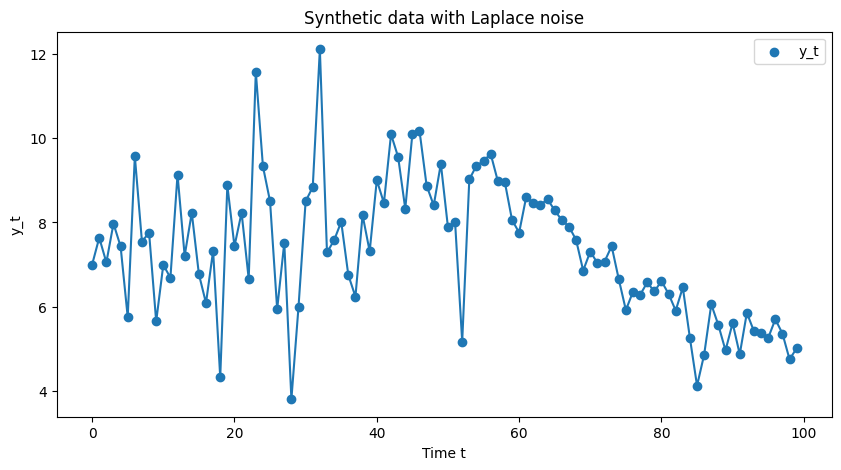

In [ ]:
plt.figure(figsize=(10, 5))
plt.scatter(t, y, marker="o", label="y_t")
plt.plot(t, y)
plt.xlabel("Time t")
plt.ylabel("y_t")
plt.title("Synthetic data with Laplace noise")
plt.legend()
plt.show()

## 3. Model, features and loss

In [ ]:
def minmax_normalize_time(t):
    t = np.asarray(t, dtype=np.float32)
    tmin, tmax = t.min(), t.max()
    return ((t - tmin) / (tmax - tmin)).astype(np.float32).reshape(-1, 1)

class Sine(nn.Module):
    def forward(self, x):
        return torch.sin(x)

ACTIVATIONS = {
    "relu": nn.ReLU,
    "tanh": nn.Tanh,
    "silu": nn.SiLU,
    "gelu": nn.GELU,
    "softplus": nn.Softplus,
    "sine": Sine,
}

def build_time_features(t_norm, feature_mode):
    x = t_norm
    if feature_mode == "raw":
        return x
    if feature_mode == "raw2":
        return torch.cat([x, x**2], dim=1)
    if feature_mode == "fourier2":
        feats = [x]
        for k in range(1, 3):
            feats += [torch.sin(2.0 * math.pi * k * x), torch.cos(2.0 * math.pi * k * x)]
        return torch.cat(feats, dim=1)
    if feature_mode == "fourier4":
        feats = [x]
        for k in range(1, 5):
            feats += [torch.sin(2.0 * math.pi * k * x), torch.cos(2.0 * math.pi * k * x)]
        return torch.cat(feats, dim=1)
    raise ValueError(f"Unknown feature_mode={feature_mode!r}")

class ParameterMLP(nn.Module):
    def __init__(self, input_dim, hidden_units, activation, constrain_phi):
        super().__init__()
        layers = []
        prev_dim = input_dim
        activation_cls = ACTIVATIONS[activation]
        for units in hidden_units:
            layers += [nn.Linear(prev_dim, units), activation_cls()]
            prev_dim = units
        self.trunk = nn.Sequential(*layers) if layers else nn.Identity()
        self.c_head = nn.Linear(prev_dim, 1)
        self.phi_head = nn.Linear(prev_dim, 1)
        self.log_scale_head = nn.Linear(prev_dim, 1)
        self.constrain_phi = constrain_phi

    def forward(self, x):
        h = self.trunk(x)
        c = self.c_head(h)
        phi = self.phi_head(h)
        if self.constrain_phi:
            phi = 0.99 * torch.tanh(phi)
        log_scale = self.log_scale_head(h).clamp(-12.0, 12.0)
        return torch.cat([c, phi, log_scale], dim=1)

def laplace_ar1_loss(y_true, y_pred, *, valid_from_index=1, smoothness_weight=0.0, eps=1e-12):
    y_prev = y_true[valid_from_index - 1 : -1, 0]
    y_curr = y_true[valid_from_index:, 0]

    c = y_pred[valid_from_index:, 0]
    phi = y_pred[valid_from_index:, 1]
    log_b = y_pred[valid_from_index:, 2]
    b = torch.exp(log_b).clamp_min(eps)

    resid = y_curr - c - phi * y_prev
    base = torch.sum(torch.log(b) + torch.abs(resid) / b)

    if smoothness_weight > 0.0:
        diffs = y_pred[valid_from_index:, :] - y_pred[valid_from_index - 1 : -1, :]
        base = base + smoothness_weight * torch.mean(diffs**2)
    return base

def unpack_predictions(pred_np, noise="laplace"):
    log_scale = np.clip(pred_np[:, 2], -12.0, 12.0)
    scale = np.exp(log_scale)
    if noise == "laplace":
        b = scale.astype(np.float32)
        sigma = (np.sqrt(2.0) * b).astype(np.float32)
        return {
            "c": pred_np[:, 0].astype(np.float32),
            "phi": pred_np[:, 1].astype(np.float32),
            "b": b,
            "sigma": sigma,
            "log_scale": log_scale.astype(np.float32),
        }
    raise ValueError("This notebook is only for Laplace")

def mse_metrics(reference, predicted, noise="laplace"):
    out = {}
    scale_name = "b"
    for name in ("c", "phi", scale_name):
        err = np.asarray(predicted[name]) - np.asarray(reference[name])
        out[f"mse_{name}"] = float(np.mean(np.square(err)))
        out[f"rmse_{name}"] = float(np.sqrt(out[f"mse_{name}"]))
        out[f"mae_{name}"] = float(np.mean(np.abs(err)))
    ref_var = {name: float(np.var(reference[name])) for name in ("c", "phi", scale_name)}
    out["mse_mean_raw"] = float((out["mse_c"] + out["mse_phi"] + out[f"mse_{scale_name}"]) / 3.0)
    out["mse_mean_norm"] = float((
        out["mse_c"] / max(ref_var["c"], 1e-12) +
        out["mse_phi"] / max(ref_var["phi"], 1e-12) +
        out[f"mse_{scale_name}"] / max(ref_var[scale_name], 1e-12)
    ) / 3.0)
    return out

## 4. Build the exact model selected by grid search

In [ ]:
torch.manual_seed(INIT_SEED)
np.random.seed(INIT_SEED)

t_norm_np = minmax_normalize_time(t)
x = torch.tensor(t_norm_np, dtype=torch.float32)
x = build_time_features(x, model_config["feature_mode"])
y_tensor = torch.tensor(np.asarray(y, dtype=np.float32)[:, None], dtype=torch.float32)

model = ParameterMLP(
    input_dim=x.shape[1],
    hidden_units=tuple(model_config["hidden_units"]),
    activation=str(model_config["activation"]),
    constrain_phi=bool(model_config["constrain_phi"]),
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=float(training_config["learning_rate"]),
    weight_decay=float(training_config["weight_decay"]),
)

print(model)

ParameterMLP(
  (trunk): Sequential(
    (0): Linear(in_features=1, out_features=16, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): GELU(approximate='none')
    (4): Linear(in_features=16, out_features=16, bias=True)
    (5): GELU(approximate='none')
  )
  (c_head): Linear(in_features=16, out_features=1, bias=True)
  (phi_head): Linear(in_features=16, out_features=1, bias=True)
  (log_scale_head): Linear(in_features=16, out_features=1, bias=True)
)


## 5. Train model

In [ ]:
best_metric = float("inf")
best_epoch = 0
best_loss = float("inf")
best_state = None
best_pred = None
best_metrics = None
bad_epochs = 0
history_rows = []

epochs = int(training_config["epochs"])
eval_every = int(training_config["eval_every"])
patience = int(training_config["patience"])
valid_from_index = int(training_config["valid_from_index"])
smoothness_weight = float(training_config["smoothness_weight"])
checkpoint_metric = str(training_config["checkpoint_metric"])

for epoch in range(1, epochs + 1):
    optimizer.zero_grad(set_to_none=True)
    pred_t = model(x)

    train_loss = laplace_ar1_loss(
        y_true=y_tensor,
        y_pred=pred_t,
        valid_from_index=valid_from_index,
        smoothness_weight=smoothness_weight,
    )
    train_loss.backward()
    optimizer.step()

    loss_value = float(train_loss.detach().cpu())

    if epoch % eval_every == 0 or epoch == 1 or epoch == epochs:
        with torch.no_grad():
            pred_np = model(x).cpu().numpy()

        predicted = unpack_predictions(pred_np, noise="laplace")
        metrics = mse_metrics(ref, predicted, noise="laplace")
        score = float(metrics[checkpoint_metric])

        history_rows.append({
            "epoch": float(epoch),
            "train_loss": float(loss_value),
            "score": float(score),
            "mse_mean_raw": float(metrics.get("mse_mean_raw", np.nan)),
            "mse_mean_norm": float(metrics.get("mse_mean_norm", np.nan)),
        })

        if score < best_metric - 1e-12:
            best_metric = score
            best_epoch = epoch
            best_loss = loss_value
            best_pred = pred_np.copy()
            best_metrics = metrics.copy()
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += eval_every

        if bad_epochs >= patience:
            break

if best_state is None:
    raise RuntimeError("Training finished without a saved checkpoint.")

model.load_state_dict(best_state)
history_df = pd.DataFrame(history_rows)

print("best_epoch =", best_epoch)
print("best_loss  =", best_loss)
print("best_metric=", best_metric)
print(best_metrics)

best_epoch = 1390
best_loss  = 53.373687744140625
best_metric= 0.033577420321914055
{'mse_c': 0.0741347074508667, 'rmse_c': 0.27227689481641054, 'mae_c': 0.2371429055929184, 'mse_phi': 0.0014196407282724977, 'rmse_phi': 0.03767812002041102, 'mae_phi': 0.03481387346982956, 'mse_b': 0.025177912786602974, 'rmse_b': 0.15867549523036936, 'mae_b': 0.12856031954288483, 'mse_mean_raw': 0.033577420321914055, 'mse_mean_norm': 0.1339766704306783}


## 6. Predictions and plots

In [ ]:
predicted = unpack_predictions(best_pred, noise="laplace")
pred_c = predicted["c"]
pred_phi = predicted["phi"]
pred_b = predicted["b"]

t1 = np.linspace(0, 99, 100)

c_theoretical = c_true(t1)
phi_theoretical = phi_true(t1)
b_theoretical = b_true(t1)
sigma_theoretical = sigma_true_from_b(t1)
pred_sigma = np.sqrt(2.0) * pred_b

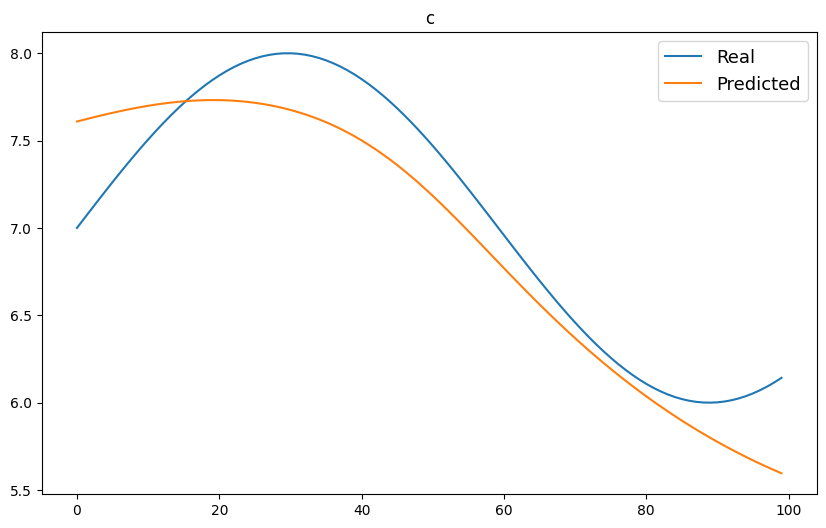

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(t, c_theoretical, linewidth=1.5, label="Real")
plt.plot(t, pred_c, linewidth=1.5, label="Predicted")
plt.title("c")
plt.legend(loc="upper right", fontsize="13")
plt.show()

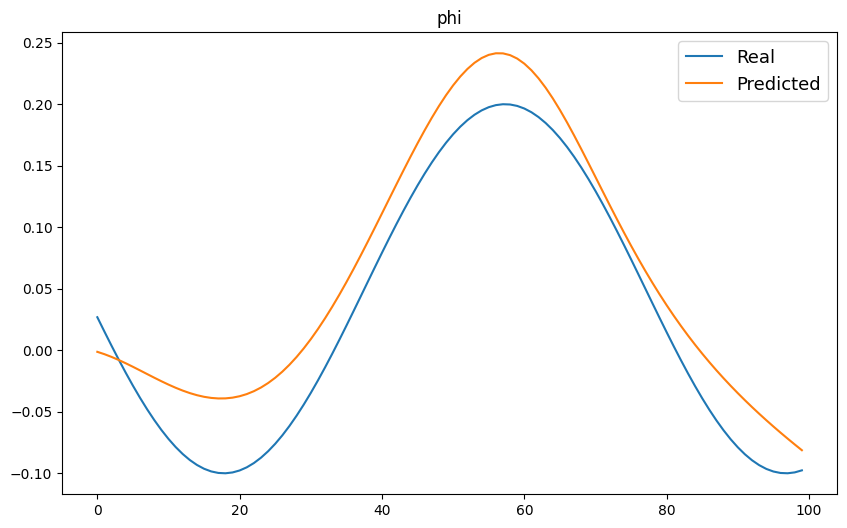

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(t, phi_theoretical, linewidth=1.5, label="Real")
plt.plot(t, pred_phi, linewidth=1.5, label="Predicted")
plt.title("phi")
plt.legend(loc="upper right", fontsize="13")
plt.show()

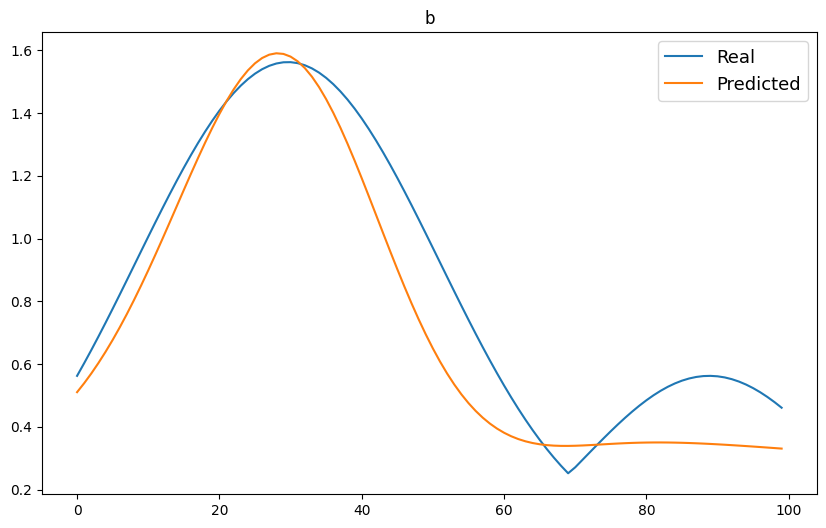

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(t, b_theoretical, linewidth=1.5, label="Real")
plt.plot(t, pred_b, linewidth=1.5, label="Predicted")
plt.title("b")
plt.legend(loc="upper right", fontsize="13")
plt.show()

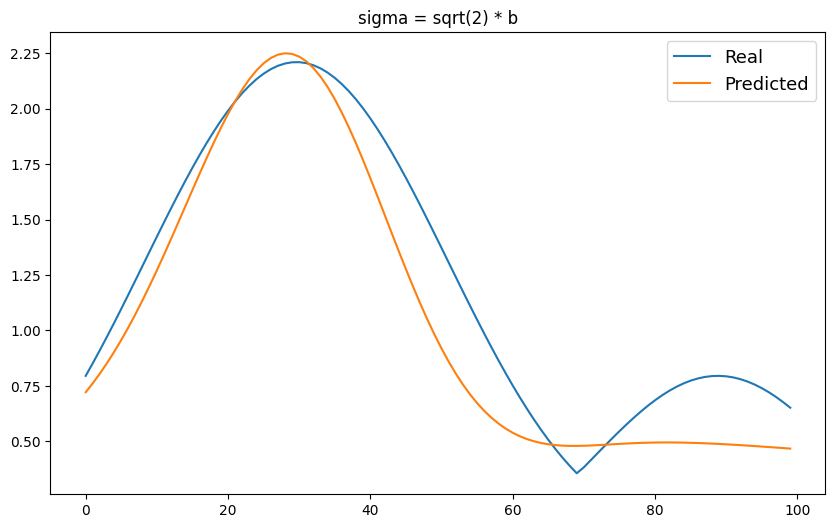

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(t, sigma_theoretical, linewidth=1.5, label="Real")
plt.plot(t, pred_sigma, linewidth=1.5, label="Predicted")
plt.title("sigma = sqrt(2) * b")
plt.legend(loc="upper right", fontsize="13")
plt.show()

## 7. Errors

In [ ]:
from sklearn.metrics import mean_squared_error

mse_c = mean_squared_error(c_theoretical, pred_c)
mse_phi = mean_squared_error(phi_theoretical, pred_phi)
mse_b = mean_squared_error(b_theoretical, pred_b)

print("mse_c   =", mse_c)
print("mse_phi =", mse_phi)
print("mse_b   =", mse_b)
print("mse_mean_raw =", (mse_c + mse_phi + mse_b) / 3.0)

mse_c   = 0.0741347074508667
mse_phi = 0.0014196407282724977
mse_b   = 0.025177912786602974
mse_mean_raw = 0.033577420321914055


## 8. Compare with grid-search summary

In [ ]:
print("Best metrics reported by grid search:")
best_metrics_from_grid

Best metrics reported by grid search:


{'stage': 'multistart',
 'init_seed': 4,
 'best_epoch': 1390,
 'best_loss': 53.373687744140625,
 'best_metric': 0.033577420321914055,
 'hidden_units': '[16, 16, 16]',
 'activation': 'gelu',
 'constrain_phi': False,
 'feature_mode': 'raw',
 'epochs': 2500,
 'learning_rate': 0.003,
 'weight_decay': 0.0,
 'smoothness_weight': 0.0,
 'valid_from_index': 1,
 'patience': 400,
 'eval_every': 10,
 'checkpoint_metric': 'mse_mean_raw',
 'mse_c': 0.0741347074508667,
 'rmse_c': 0.27227689481641054,
 'mae_c': 0.2371429055929184,
 'mse_phi': 0.0014196407282724977,
 'rmse_phi': 0.03767812002041102,
 'mae_phi': 0.03481387346982956,
 'mse_b': 0.025177912786602974,
 'rmse_b': 0.15867549523036936,
 'mae_b': 0.12856031954288483,
 'mse_mean_raw': 0.033577420321914055,
 'mse_mean_norm': 0.1339766704306783,
 'manual_name': nan}

In [ ]:
history_df.head(), history_df.tail()


(   epoch  train_loss      score  mse_mean_raw  mse_mean_norm
 0    1.0  603.340820  16.465468     16.465468      31.633177
 1   10.0  398.748291  16.028915     16.028915      33.506139
 2   20.0  140.333267  15.655945     15.655945      56.426692
 3   30.0  165.556198  15.603938     15.603938      63.656739
 4   40.0  139.782333  15.423517     15.423517      47.789379,
       epoch  train_loss     score  mse_mean_raw  mse_mean_norm
 175  1750.0   51.533409  0.098996      0.098996       0.316566
 176  1760.0   51.633450  0.090195      0.090195       0.332574
 177  1770.0   52.979057  0.104117      0.104117       0.322328
 178  1780.0   52.414829  0.105865      0.105865       0.316631
 179  1790.0   52.463245  0.106745      0.106745       0.336932)

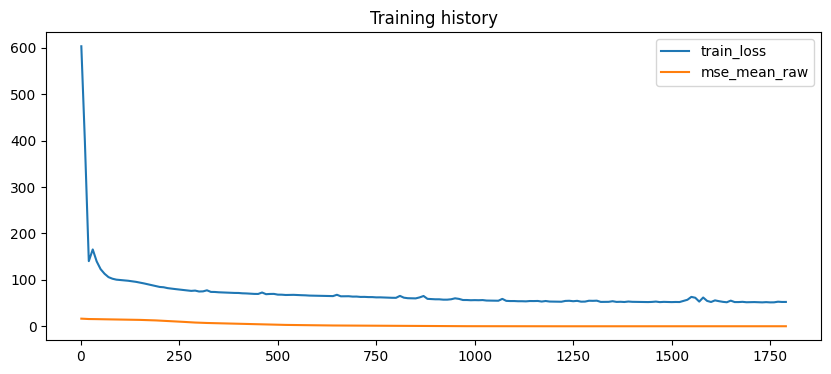

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
plt.plot(history_df["epoch"], history_df["mse_mean_raw"], label="mse_mean_raw")
plt.legend()
plt.title("Training history")
plt.show()